In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
#load dataset
df = pd.read_csv(r"C:\Users\diviy\OneDrive\Documents\SmartStudy_ML Project\dataset\student_performance.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [6]:
#basic data inspection
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

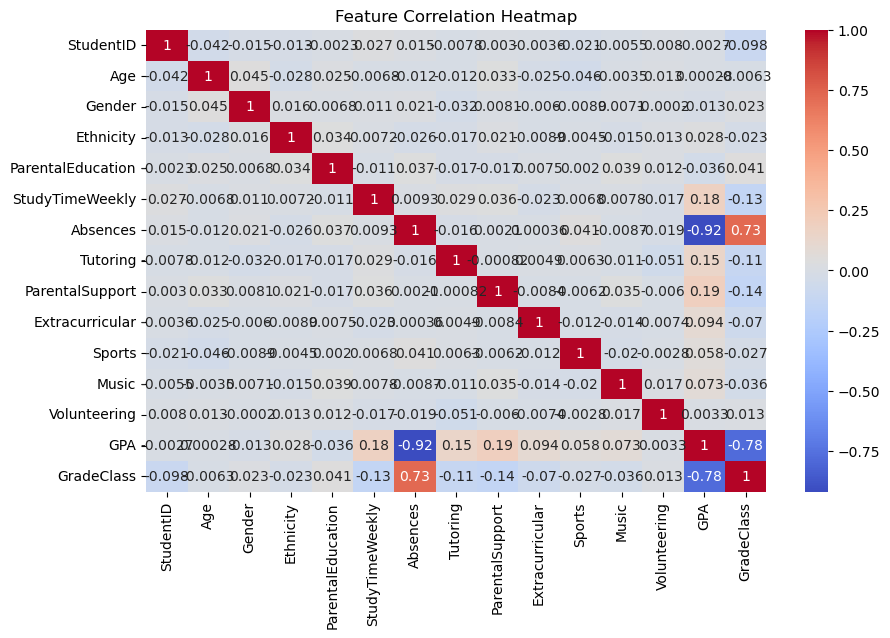

In [7]:
#correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [70]:
#remove old cluster
if "Cluster" in df.columns:
    df = df.drop("Cluster", axis=1)

In [71]:
# store student IDs
student_ids = df["StudentID"]

# feature selection (X-input features,y-target variables)
X = df.drop(["StudentID", "GPA", "GradeClass"], axis=1)
y = df["GPA"]

In [72]:
#feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

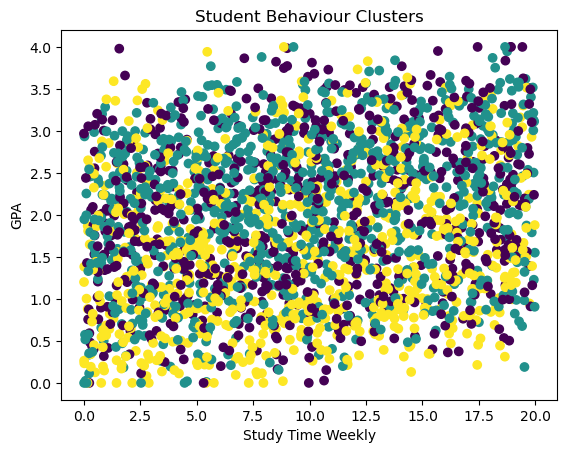

In [73]:
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# cluster visualization
plt.scatter(df["StudyTimeWeekly"], df["GPA"], c=df["Cluster"], cmap="viridis")
plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")
plt.title("Student Behaviour Clusters")
plt.show()

In [74]:
#train regression model
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

#prediction
y_pred = model.predict(X_test)

In [76]:
#model evaluation
#predict error
mae = mean_absolute_error(y_test, y_pred)
#squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#model accuracy
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.15529483485748105
RMSE: 0.19662512935670914
R2 Score: 0.9532471681022928


In [78]:
new_student = pd.DataFrame([[
17,  # Age
1,   # Gender
0,   # Ethnicity
2,   # ParentalEducation
15,  # StudyTimeWeekly
3,   # Absences
1,   # Tutoring
2,   # ParentalSupport
0,   # Extracurricular
1,   # Sports
0,   # Music
0    # Volunteering
]], columns=X.columns)

# scale input
new_student_scaled = scaler.transform(new_student)

# predict GPA
predicted_gpa = model.predict(new_student_scaled)

print("Predicted GPA:", predicted_gpa[0])

Predicted GPA: 3.3943620711149753


In [94]:
# Convert GPA from 4-scale to 10-scale
gpa_10 = (predicted_gpa[0] / 4) * 10

# Determine performance level
if predicted_gpa[0] >= 3.5:
    performance = "Excellent"
elif predicted_gpa[0] >= 3.0:
    performance = "Good"
elif predicted_gpa[0] >= 2.0:
    performance = "Average"
else:
    performance = "At Risk"

# Display results
print("Predicted GPA (4 scale):", round(predicted_gpa[0], 2))
print("Predicted GPA (10 scale):", round(gpa_10, 2))
print("Performance Level:", performance)

print("\nSuggestions for Improvement:")

study_time = new_student["StudyTimeWeekly"].values[0]
absences = new_student["Absences"].values[0]
parent_support = new_student["ParentalSupport"].values[0]

if study_time < 10:
    print("- Increase weekly study time to improve academic performance.")

if absences > 5:
    print("- Reduce class absences. Regular attendance improves GPA.")

if parent_support < 2:
    print("- Seek more academic guidance from parents or mentors.")

if study_time >= 10 and absences <= 5:
    print("- Good academic habits. Maintain your current study routine.")

Predicted GPA (4 scale): 3.39
Predicted GPA (10 scale): 8.49
Performance Level: Good

Suggestions for Improvement:
- Good academic habits. Maintain your current study routine.


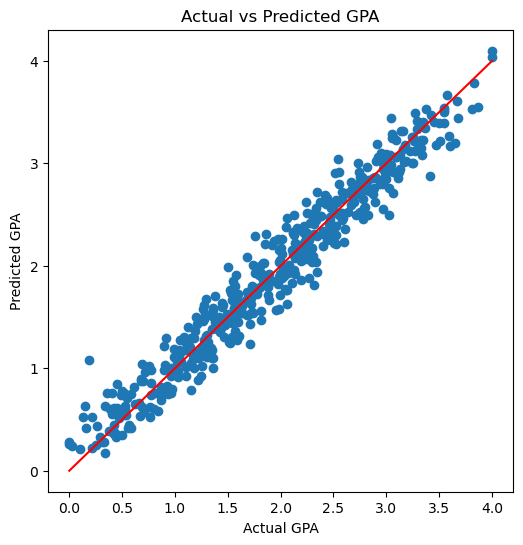

In [86]:
#model visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")

plt.plot([y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
color='red')

plt.show()

In [87]:
print("Number of students in each cluster:")
print(df["Cluster"].value_counts())

Number of students in each cluster:
Cluster
1    909
2    758
0    725
Name: count, dtype: int64


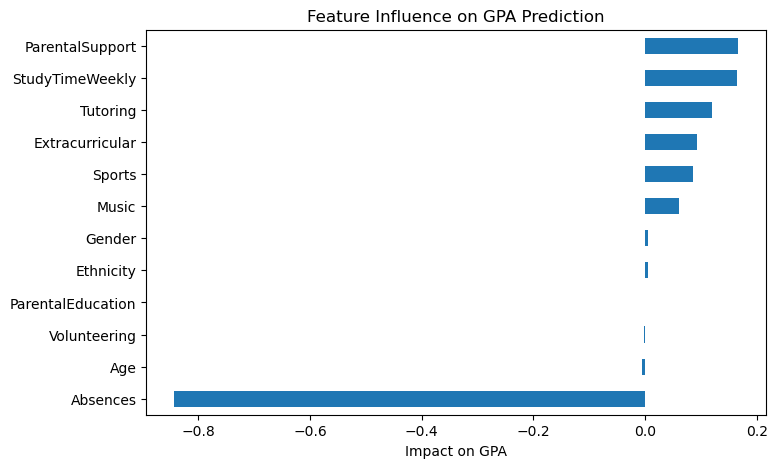

In [88]:
#feature importance graph
feature_importance = pd.Series(model.coef_, index=X.columns)

feature_importance.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Influence on GPA Prediction")
plt.xlabel("Impact on GPA")

plt.show()

In [89]:
print("\nFeature Importance (Impact on GPA):\n")
feature_importance_sorted = feature_importance.sort_values(ascending=False)
print(feature_importance_sorted)


Feature Importance (Impact on GPA):

ParentalSupport      0.165960
StudyTimeWeekly      0.164115
Tutoring             0.118510
Extracurricular      0.092158
Sports               0.085054
Music                0.060637
Gender               0.005257
Ethnicity            0.004879
ParentalEducation    0.000125
Volunteering        -0.001922
Age                 -0.006443
Absences            -0.842478
dtype: float64


In [92]:
#explains why GPA prediction happened
print("\nStudent Factor Analysis:\n")

student_values = new_student.iloc[0]

for feature in X.columns:
    
    student_value = student_values[feature]
    avg_value = df[feature].mean()
    
    if student_value < avg_value:
        status = "Below Average"
    else:
        status = "Above Average"
        
    impact = feature_importance[feature]
    
    print(f"{feature}: {status} | Impact on GPA: {impact:.3f}")


Student Factor Analysis:

Age: Above Average | Impact on GPA: -0.006
Gender: Above Average | Impact on GPA: 0.005
Ethnicity: Below Average | Impact on GPA: 0.005
ParentalEducation: Above Average | Impact on GPA: 0.000
StudyTimeWeekly: Above Average | Impact on GPA: 0.164
Absences: Below Average | Impact on GPA: -0.842
Tutoring: Above Average | Impact on GPA: 0.119
ParentalSupport: Below Average | Impact on GPA: 0.166
Extracurricular: Below Average | Impact on GPA: 0.092
Sports: Above Average | Impact on GPA: 0.085
Music: Below Average | Impact on GPA: 0.061
Volunteering: Below Average | Impact on GPA: -0.002


In [93]:
print("\nImportant Factors Affecting This Student:\n")

for feature in X.columns:
    
    student_value = new_student.iloc[0][feature]
    avg_value = df[feature].mean()
    impact = feature_importance[feature]
    
    if impact < -0.1 and student_value > avg_value:
        print(f"- {feature} is high and negatively affects GPA.")

    if impact > 0.1 and student_value < avg_value:
        print(f"- {feature} is low and should be improved to increase GPA.")


Important Factors Affecting This Student:

- ParentalSupport is low and should be improved to increase GPA.
